# Indicators of Anxiety or Depression (Household Pulse Survey)

This notebook analyzes weekly U.S. Census Bureau Household Pulse Survey estimates of mental health symptoms reported during the last 7 days.

## Goals
- Explore national trends for anxiety and depression indicators  
- Compare anxiety vs. depression over time  
- Check whether trends are statistically significant  
- Compare demographic groups (Age) for recent periods  
- Produce publication-ready visualizations  


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm

# This notebook also works as-is in this environment using the absolute path fallback.
REL_PATH = "../data/Indicators_of_Anxiety_or_Depression_Based_on_Reported_Frequency_of_Symptoms_During_Last_7_Days.csv"
ABS_PATH = "../data/Indicators_of_Anxiety_or_Depression_Based_on_Reported_Frequency_of_Symptoms_During_Last_7_Days.csv"

DATA_PATH = REL_PATH if os.path.exists(REL_PATH) else ABS_PATH

df = pd.read_csv(DATA_PATH)
print("Using:", DATA_PATH)
print("Shape:", df.shape)
df.head()


Using: /mnt/data/Indicators_of_Anxiety_or_Depression_Based_on_Reported_Frequency_of_Symptoms_During_Last_7_Days.csv
Shape: (16794, 14)


,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,Low CI,High CI,Confidence Interval,Quartile Range
0,Symptoms of Depressive Disorder,National Estimate,United States,United States,1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,23.5,22.7,24.3,22.7 - 24.3,NaN
1,Symptoms of Depressive Disorder,By Age,United States,18 - 29 years,1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,32.7,30.2,35.2,30.2 - 35.2,NaN
2,Symptoms of Depressive Disorder,By Age,United States,30 - 39 years,1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,25.7,24.1,27.3,24.1 - 27.3,NaN
3,Symptoms of Depressive Disorder,By Age,United States,40 - 49 years,1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,24.8,23.3,26.2,23.3 - 26.2,NaN
4,Symptoms of Depressive Disorder,By Age,United States,50 - 59 years,1,1,"Apr 23 - May 5, 2020",04/23/2020,05/05/2020,23.2,21.5,25.0,21.5 - 25.0,NaN


## Data overview

In [2]:
df.dtypes

Indicator                  object
Group                      object
State                      object
Subgroup                   object
Phase                      object
Time Period                 int64
Time Period Label          object
Time Period Start Date     object
Time Period End Date       object
Value                     float64
Low CI                    float64
High CI                   float64
Confidence Interval        object
Quartile Range             object
dtype: object

In [3]:
df["Indicator"].value_counts().head(10)

Indicator
Symptoms of Depressive Disorder                        5598
Symptoms of Anxiety Disorder                           5598
Symptoms of Anxiety Disorder or Depressive Disorder    5598
Name: count, dtype: int64

In [4]:
df["Group"].value_counts().head(10)

Group
By State                      11016
By Age                         1722
By Race/Hispanic ethnicity     1230
By Education                    984
By Sex                          492
By Gender identity              396
By Sexual orientation           396
By Disability status            312
National Estimate               246
Name: count, dtype: int64

## Cleaning & basic preparation

In [5]:
# Parse dates and numeric value
df["Time Period Start Date"] = pd.to_datetime(df["Time Period Start Date"])
df["Time Period End Date"] = pd.to_datetime(df["Time Period End Date"])
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

df = df.dropna(subset=["Value"]).copy()

print("Rows after dropping missing Value:", len(df))
df[["Time Period Start Date","Indicator","Group","Subgroup","Value"]].head()


Rows after dropping missing Value: 16087


,Time Period Start Date,Indicator,Group,Subgroup,Value
0,2020-04-23,Symptoms of Depressive Disorder,National Estimate,United States,23.5
1,2020-04-23,Symptoms of Depressive Disorder,By Age,18 - 29 years,32.7
2,2020-04-23,Symptoms of Depressive Disorder,By Age,30 - 39 years,25.7
3,2020-04-23,Symptoms of Depressive Disorder,By Age,40 - 49 years,24.8
4,2020-04-23,Symptoms of Depressive Disorder,By Age,50 - 59 years,23.2


## 1) National trends: Anxiety vs Depression

In [6]:
# National estimates for the US
national = df[(df["Group"]=="National Estimate") & (df["State"]=="United States")].copy()
national = national.sort_values("Time Period Start Date")

anx_label = [x for x in national["Indicator"].unique() if "Anxiety" in x][0]
dep_label = [x for x in national["Indicator"].unique() if "Depressive" in x][0]

anx = national[national["Indicator"]==anx_label][["Time Period Start Date","Value"]].rename(columns={"Value":"Anxiety"})
dep = national[national["Indicator"]==dep_label][["Time Period Start Date","Value"]].rename(columns={"Value":"Depression"})

ts = pd.merge(anx, dep, on="Time Period Start Date", how="inner").sort_values("Time Period Start Date")

print("Anxiety indicator:", anx_label)
print("Depression indicator:", dep_label)
print("Number of matched weeks:", len(ts))
ts.head()


Anxiety indicator: Symptoms of Anxiety Disorder
Depression indicator: Symptoms of Depressive Disorder
Number of matched weeks: 72


,Time Period Start Date,Anxiety,Depression
0,2020-04-23,30.8,23.5
1,2020-05-07,30.0,24.1
2,2020-05-14,28.2,24.4
3,2020-05-21,29.4,24.9
4,2020-05-28,30.6,25.3


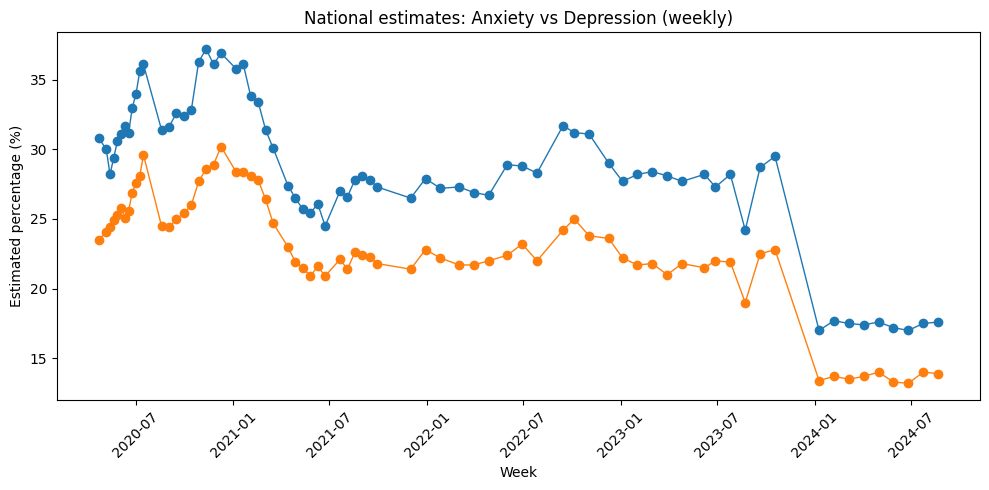

In [7]:
plt.figure(figsize=(10,5))
plt.plot(ts["Time Period Start Date"], ts["Anxiety"], marker="o", linewidth=1)
plt.plot(ts["Time Period Start Date"], ts["Depression"], marker="o", linewidth=1)
plt.title("National estimates: Anxiety vs Depression (weekly)")
plt.xlabel("Week")
plt.ylabel("Estimated percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [8]:
summary = pd.DataFrame({
    "mean_%": ts[["Anxiety","Depression"]].mean(),
    "std_%": ts[["Anxiety","Depression"]].std(),
    "min_%": ts[["Anxiety","Depression"]].min(),
    "max_%": ts[["Anxiety","Depression"]].max(),
}).round(2)

summary


,mean_%,std_%,min_%,max_%
Anxiety,28.39,5.21,17.0,37.2
Depression,22.70,4.23,13.2,30.2


## 2) Anxiety vs Depression over time (paired comparison)

We treat each week as a paired observation and run a paired t-test on the weekly difference (Anxiety − Depression).

In [9]:
diff = ts["Anxiety"] - ts["Depression"]

t_stat, p_val = stats.ttest_rel(ts["Anxiety"], ts["Depression"], nan_policy="omit")

# Effect size (Cohen's d for paired samples)
d = diff.mean() / diff.std(ddof=1)

print(f"Mean difference (Anxiety - Depression): {diff.mean():.3f} percentage points")
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val:.3g}")
print(f"Cohen's d (paired): {d:.3f}")


Mean difference (Anxiety - Depression): 5.685 percentage points
Paired t-test: t = 37.880, p = 7.82e-49
Cohen's d (paired): 4.464


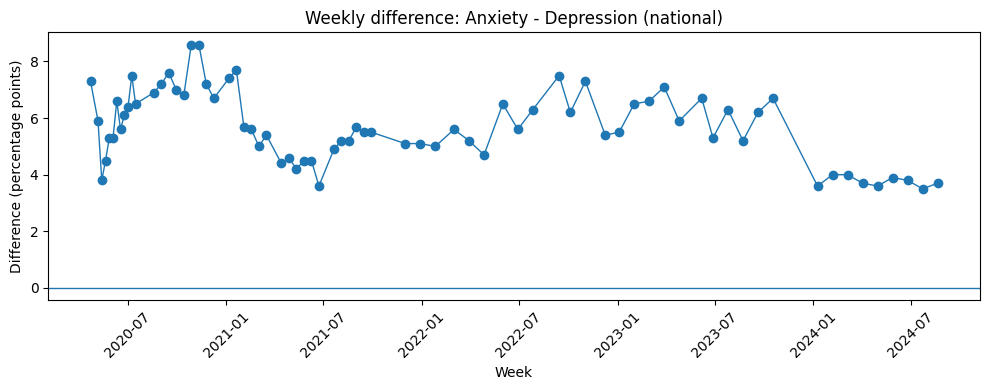

In [10]:
plt.figure(figsize=(10,4))
plt.plot(ts["Time Period Start Date"], diff, marker="o", linewidth=1)
plt.axhline(0, linewidth=1)
plt.title("Weekly difference: Anxiety - Depression (national)")
plt.xlabel("Week")
plt.ylabel("Difference (percentage points)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 3) Are trends statistically significant?

We test trend significance in two ways:
- **OLS regression** of Value on time index (slope and p-value)
- **Spearman correlation** between time and Value (robust to non-normality)

In [11]:
ts2 = ts.copy()
ts2["t"] = np.arange(len(ts2))

def trend_tests(series, t):
    X = sm.add_constant(t)
    model = sm.OLS(series, X).fit()
    slope = model.params[1]
    slope_p = model.pvalues[1]
    rho, rho_p = stats.spearmanr(t, series)
    return slope, slope_p, rho, rho_p

anx_slope, anx_slope_p, anx_rho, anx_rho_p = trend_tests(ts2["Anxiety"].values, ts2["t"].values)
dep_slope, dep_slope_p, dep_rho, dep_rho_p = trend_tests(ts2["Depression"].values, ts2["t"].values)

trend_table = pd.DataFrame({
    "Indicator": ["Anxiety", "Depression"],
    "OLS_slope_(pp_per_week)": [anx_slope, dep_slope],
    "OLS_p_value": [anx_slope_p, dep_slope_p],
    "Spearman_rho": [anx_rho, dep_rho],
    "Spearman_p_value": [anx_rho_p, dep_rho_p],
}).round(4)

trend_table


,Indicator,OLS_slope_(pp_per_week),OLS_p_value,Spearman_rho,Spearman_p_value
0,Anxiety,-0.1792,0.0,-0.6724,0.0
1,Depression,-0.1553,0.0,-0.7588,0.0


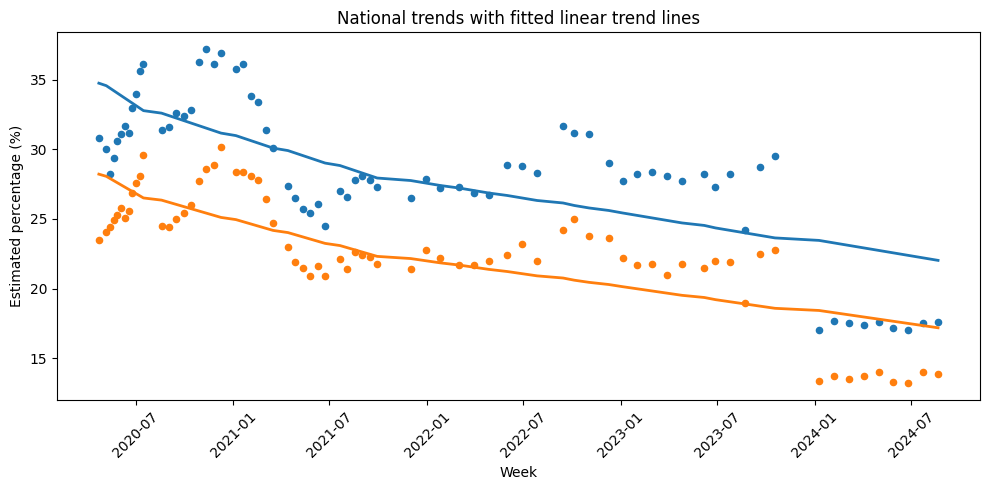

In [12]:
# Regression lines for a cleaner trend view
plt.figure(figsize=(10,5))
plt.scatter(ts2["Time Period Start Date"], ts2["Anxiety"], s=20)
plt.scatter(ts2["Time Period Start Date"], ts2["Depression"], s=20)

# Fit lines using numpy polyfit on index
anx_line = np.poly1d(np.polyfit(ts2["t"], ts2["Anxiety"], 1))(ts2["t"])
dep_line = np.poly1d(np.polyfit(ts2["t"], ts2["Depression"], 1))(ts2["t"])

plt.plot(ts2["Time Period Start Date"], anx_line, linewidth=2)
plt.plot(ts2["Time Period Start Date"], dep_line, linewidth=2)

plt.title("National trends with fitted linear trend lines")
plt.xlabel("Week")
plt.ylabel("Estimated percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4) Demographic comparison: Age groups (latest available week)

We compare Age subgroups for the most recent time period in the dataset.

Statistical tests:
- **One-way ANOVA** across age groups
- **Kruskal–Wallis** non-parametric test across age groups

We run each test separately for anxiety and depression indicators.

In [13]:
age = df[(df["Group"]=="By Age") & (df["State"]=="United States")].copy()
latest_start = age["Time Period Start Date"].max()
age_latest = age[age["Time Period Start Date"]==latest_start].copy()

print("Latest week start date (age group data):", latest_start.date())
age_latest[["Indicator","Subgroup","Value"]].head()


Latest week start date (age group data): 2024-08-20


,Indicator,Subgroup,Value
16561,Symptoms of Depressive Disorder,18 - 29 years,24.1
16562,Symptoms of Depressive Disorder,30 - 39 years,17.5
16563,Symptoms of Depressive Disorder,40 - 49 years,12.8
16564,Symptoms of Depressive Disorder,50 - 59 years,13.9
16565,Symptoms of Depressive Disorder,60 - 69 years,9.7


In [14]:
# Build a tidy table with both indicators side-by-side
age_anx = age_latest[age_latest["Indicator"]==anx_label][["Subgroup","Value"]].rename(columns={"Value":"Anxiety"})
age_dep = age_latest[age_latest["Indicator"]==dep_label][["Subgroup","Value"]].rename(columns={"Value":"Depression"})

age_tbl = pd.merge(age_anx, age_dep, on="Subgroup", how="inner").sort_values("Subgroup")
age_tbl


,Subgroup,Anxiety,Depression
0,18 - 29 years,30.2,24.1
1,30 - 39 years,24.4,17.5
2,40 - 49 years,17.7,12.8
3,50 - 59 years,16.3,13.9
4,60 - 69 years,10.6,9.7
5,70 - 79 years,7.1,6.1
6,80 years and above,6.8,6.4


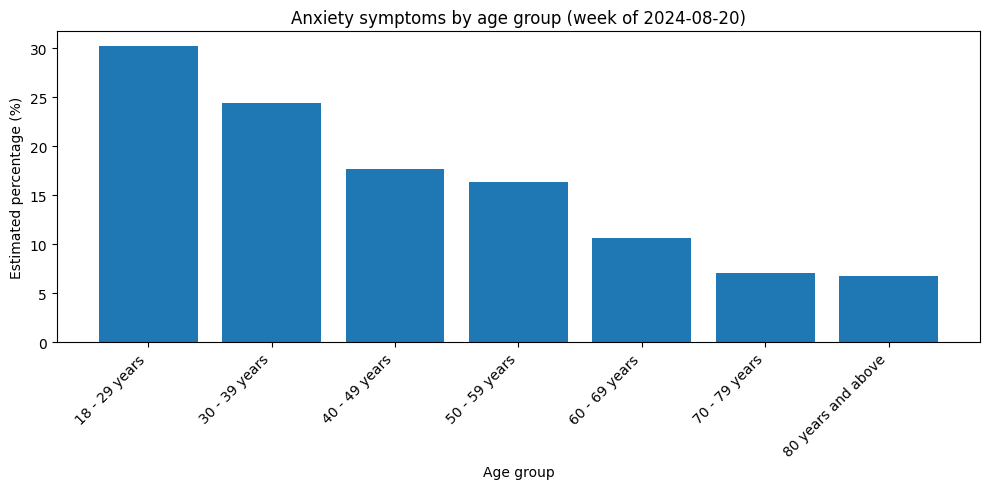

In [15]:
# Bar chart (sorted by Anxiety)
age_plot = age_tbl.sort_values("Anxiety", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(age_plot["Subgroup"], age_plot["Anxiety"])
plt.title(f"Anxiety symptoms by age group (week of {latest_start.date()})")
plt.xlabel("Age group")
plt.ylabel("Estimated percentage (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


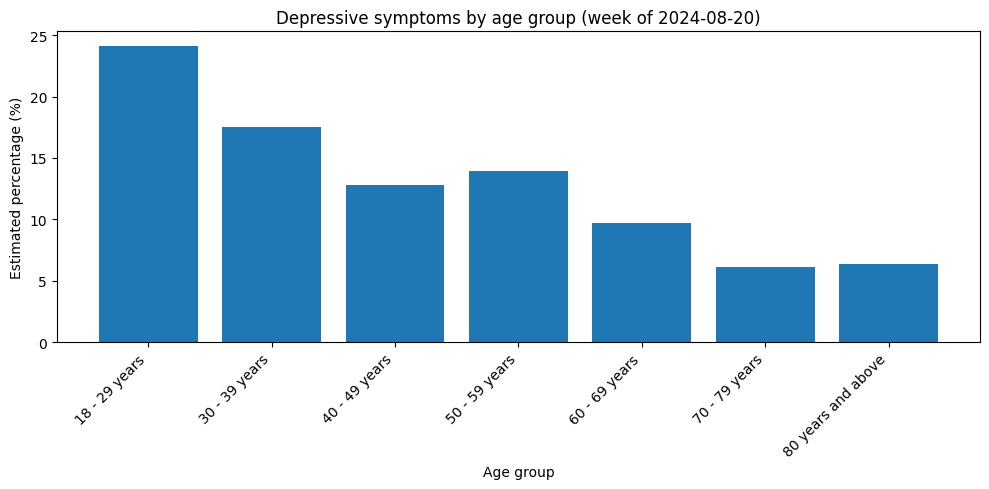

In [16]:
plt.figure(figsize=(10,5))
plt.bar(age_plot["Subgroup"], age_plot["Depression"])
plt.title(f"Depressive symptoms by age group (week of {latest_start.date()})")
plt.xlabel("Age group")
plt.ylabel("Estimated percentage (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [17]:
# One-way ANOVA and Kruskal-Wallis across age groups
anx_groups = [g["Anxiety"].values for _, g in age_tbl.groupby("Subgroup")]
dep_groups = [g["Depression"].values for _, g in age_tbl.groupby("Subgroup")]

# Each subgroup is one value for the latest week, so ANOVA/KW on singletons isn't meaningful.
# Instead, compare age groups across ALL weeks (richer sample).
age_all = df[(df["Group"]=="By Age") & (df["State"]=="United States")].copy()

def run_group_tests(indicator_label):
    sub = age_all[age_all["Indicator"]==indicator_label].copy()
    groups = [g["Value"].values for _, g in sub.groupby("Subgroup")]
    labels = list(sub.groupby("Subgroup").groups.keys())
    f_stat, f_p = stats.f_oneway(*groups)
    h_stat, h_p = stats.kruskal(*groups)
    return labels, f_stat, f_p, h_stat, h_p

labels, anx_f, anx_fp, anx_h, anx_hp = run_group_tests(anx_label)
_, dep_f, dep_fp, dep_h, dep_hp = run_group_tests(dep_label)

tests_tbl = pd.DataFrame({
    "Indicator": ["Anxiety", "Depression"],
    "ANOVA_F": [anx_f, dep_f],
    "ANOVA_p": [anx_fp, dep_fp],
    "Kruskal_H": [anx_h, dep_h],
    "Kruskal_p": [anx_hp, dep_hp],
}).round(4)

tests_tbl


,Indicator,ANOVA_F,ANOVA_p,Kruskal_H,Kruskal_p
0,Anxiety,290.0034,0.0,390.3760,0.0
1,Depression,274.6054,0.0,378.6552,0.0


## 5) Key takeaways (computed from the analysis)

This cell prints a short, reproducible summary that can be copied into a report/README.

In [18]:
takeaways = {
    "weeks_matched_national": int(len(ts)),
    "national_mean_anxiety_%": float(ts["Anxiety"].mean()),
    "national_mean_depression_%": float(ts["Depression"].mean()),
    "paired_mean_diff_pp": float(diff.mean()),
    "paired_t_p_value": float(p_val),
    "anxiety_trend_slope_pp_per_week": float(anx_slope),
    "anxiety_trend_p_value": float(anx_slope_p),
    "depression_trend_slope_pp_per_week": float(dep_slope),
    "depression_trend_p_value": float(dep_slope_p),
    "age_group_anova_p_anxiety": float(anx_fp),
    "age_group_anova_p_depression": float(dep_fp),
}

for k,v in takeaways.items():
    if isinstance(v, float):
        print(f"{k}: {v:.6g}")
    else:
        print(f"{k}: {v}")


weeks_matched_national: 72
national_mean_anxiety_%: 28.3889
national_mean_depression_%: 22.7042
paired_mean_diff_pp: 5.68472
paired_t_p_value: 7.82202e-49
anxiety_trend_slope_pp_per_week: -0.179153
anxiety_trend_p_value: 1.07027e-12
depression_trend_slope_pp_per_week: -0.155333
depression_trend_p_value: 3.41969e-15
age_group_anova_p_anxiety: 8.49533e-159
age_group_anova_p_depression: 2.95319e-154
